# How Reinforcement Learning Agents Learn

## Dynamic Programming, Monte Carlo, Temporal Difference, SARSA, and Q-Learning


This notebook follows the learning progression developed in the video:

$$
\boxed{
\text{MDP}
\rightarrow
\text{Model}
\rightarrow
\text{Exploration vs. Exploitation}
\rightarrow
\text{Dynamic Programming}
\rightarrow
\text{Monte Carlo}
\rightarrow
\text{Temporal Difference}
\rightarrow
\text{SARSA}
\rightarrow
\text{Q-Learning}
}
$$

The central idea is that reinforcement-learning agents improve from interaction rather than being given the correct action for every situation.

## 1. Markov Decision Processes

The interaction between an agent and an environment can be represented as a **Markov Decision Process (MDP)**.

A complete one-step dynamics function is

$$
\boxed{
p(s',r|s,a)
=
P(S_{t+1}=s',R_{t+1}=r
\mid
S_t=s,A_t=a)
}
$$

It answers:

> If the agent is in state $s$ and takes action $a$, what is the probability of receiving reward $r$ and moving to state $s'$?

### Markov Property

The MDP uses the Markov property:

$$
\boxed{
P(S_{t+1},R_{t+1}\mid S_t,A_t,\text{history})
=
P(S_{t+1},R_{t+1}\mid S_t,A_t)
}
$$

Once the current state and action are known, the full earlier trajectory is not needed to describe the next transition.

A common verbal summary is:

$$
\boxed{
\text{The future is independent of the past given the present.}
}
$$

## 2. The Environment Model

A **model** predicts how the environment will respond to an action.

Given a current state and action,

$$
(s,a),
$$

the model predicts a possible next state and reward:

$$
(s,a)
\longrightarrow
(s',r).
$$

A model can therefore generate **simulated experience**. The agent can use those predictions to evaluate possible actions and plan without physically trying every action in the real environment.

### Model-Based Reinforcement Learning

A method is **model-based** when the agent has or learns a model of the environment and uses it for planning.

The model may describe quantities such as

$$
P(s'|s,a)
$$

and

$$
R(s,a,s').
$$

### Model-Free Reinforcement Learning

A method is **model-free** when the agent learns from interaction without requiring an explicit model of the transition dynamics.

A model may be unavailable because the environment is too complex to describe accurately or because its transition probabilities are unknown.

### Why State Values Are Convenient with a Model

The state-value function tells us how good a state is:

$$
V^\pi(s)
=
\mathbb E_\pi[G_t\mid S_t=s].
$$

If the model is known, an agent can evaluate an action by predicting where that action may lead and examining the values of the possible next states.

Thus,

$$
\boxed{
\text{Model} + V(s)
\longrightarrow
\text{evaluate possible actions}
}
$$

### Why Action Values Are Useful Without a Model

Without a model, knowing only

$$
V(s)
$$

does not directly tell the agent which action should be selected.

The action-value function solves this problem:

$$
\boxed{
Q^\pi(s,a)
=
\mathbb E_\pi[G_t\mid S_t=s,A_t=a]
}
$$

It estimates the value of taking a particular action in a particular state.

The agent can then choose

$$
\boxed{
a^*
=
\arg\max_a Q(s,a)
}
$$

without first predicting the next state through an explicit model.

This is why action-value estimates are central to model-free control methods such as **SARSA** and **Q-learning**.

> This is not a strict division: model-based methods can also use $Q(s,a)$, and model-free methods can also estimate $V(s)$. The important distinction is that $Q(s,a)$ allows direct action comparison when an explicit model is unavailable.

## 3. Exploration vs. Exploitation

A model-free agent must decide whether to use what it already knows or gather more information.

### Exploitation

Choose the action with the largest current action value:

$$
\boxed{
a^*=\arg\max_a Q(s,a)
}
$$

This is **greedy action selection**.

### Exploration

Occasionally choose another action to learn more about alternatives.

### $\epsilon$-Greedy Action Selection

A simple solution is to behave greedily most of the time but choose a random action with small probability $\epsilon$.

For a greedy action $a^*$,

$$
\pi_\epsilon(a|s)
=
\begin{cases}
1-\epsilon+\dfrac{\epsilon}{|\mathcal A|},
& a=a^*,\\[6pt]
\dfrac{\epsilon}{|\mathcal A|},
& a\ne a^*.
\end{cases}
$$

During training, $\epsilon$ can be gradually reduced:

$$
\boxed{
\text{large exploration early}
\rightarrow
\text{more exploitation later}
}
$$

In [1]:
import random
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

def epsilon_greedy(q_values, epsilon=0.1, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    actions = np.arange(len(q_values))

    if rng.random() < epsilon:
        return int(rng.choice(actions))

    best_actions = np.flatnonzero(np.isclose(q_values, np.max(q_values)))
    return int(rng.choice(best_actions))

q_demo = np.array([4.0, 2.0, 3.0, 7.0])
rng = np.random.default_rng(SEED)

samples = [epsilon_greedy(q_demo, epsilon=0.1, rng=rng) for _ in range(1000)]
counts = pd.Series(samples).value_counts().sort_index()

print("Q-values:", q_demo)
print("Greedy action index:", int(np.argmax(q_demo)))
print("\nSelections from 1,000 epsilon-greedy decisions:")
print(counts)

Q-values: [4. 2. 3. 7.]
Greedy action index: 3

Selections from 1,000 epsilon-greedy decisions:
0     29
1     31
2     21
3    919
Name: count, dtype: int64


## 4. How Policies and Value Functions Can Be Represented

In small reinforcement-learning problems, policies and value functions can be stored in **tables**.

For example:

- one row per state for $V(s)$,
- one row per state and one entry per action for $Q(s,a)$ or $\pi(a|s)$.

For large state spaces, storing every state explicitly becomes impractical. Functions can instead be approximated using parameterized models such as neural networks.

The early methods in this notebook use the **tabular setting** because it makes the learning logic easy to see.

# 5. Dynamic Programming

Dynamic Programming (DP) assumes that the environment model is available.

A crucial idea is that a value function is always tied to a policy.

If the policy changes,

$$
\pi \rightarrow \pi',
$$

the agent behaves differently, receives different rewards, obtains different returns, and therefore generally has different values:

$$
V^\pi(s)\neq V^{\pi'}(s).
$$

### Recursive Form of the State Value

The return can be decomposed as

$$
G_t
=
R_{t+1}
+
\gamma G_{t+1}.
$$

Therefore,

$$
V^\pi(s)
=
\mathbb E_\pi
\left[
R_{t+1}
+
\gamma V^\pi(S_{t+1})
\mid
S_t=s
\right].
$$

For a finite MDP,

$$
\boxed{
V^\pi(s)
=
\sum_a
\pi(a|s)
\sum_{s',r}
p(s',r|s,a)
\left[
r+\gamma V^\pi(s')
\right]
}
$$

## 5.1 Policy Evaluation: Prediction Problem

**Policy evaluation** estimates the value function for a fixed policy.

Given policy $\pi$:

1. Initialize $V(s)$, often to zero.
2. For every nonterminal state, update the value using the Bellman expectation equation.
3. Repeat the sweep until the values stabilize.

This answers the **prediction problem**:

> How good is the current policy?

## 5.2 The 4×4 GridWorld Example

The video uses a $4\times4$ GridWorld:

- top-left and bottom-right cells are terminal,
- the other $14$ cells are nonterminal states,
- actions are `Up`, `Down`, `Left`, and `Right`,
- every transition gives reward $-1$,
- attempting to move outside the grid leaves the agent in the same state,
- the initial policy chooses all four actions uniformly at random,
- all state values begin at $0$.

The random policy is

$$
\pi(a|s)=\frac14
$$

for all four actions.

In [2]:
class GridWorld4x4:
    def __init__(self):
        self.rows = 4
        self.cols = 4
        self.terminals = {(0, 0), (3, 3)}
        self.actions = ("Up", "Down", "Left", "Right")
        self.states = [(r, c) for r in range(4) for c in range(4)]

    def step(self, state, action):
        if state in self.terminals:
            return state, 0, True

        r, c = state

        if action == "Up":
            nr, nc = max(r - 1, 0), c
        elif action == "Down":
            nr, nc = min(r + 1, 3), c
        elif action == "Left":
            nr, nc = r, max(c - 1, 0)
        elif action == "Right":
            nr, nc = r, min(c + 1, 3)
        else:
            raise ValueError("Invalid action")

        next_state = (nr, nc)
        return next_state, -1, next_state in self.terminals

grid = GridWorld4x4()

In [3]:
def evaluate_uniform_random_policy(env, gamma=1.0, tolerance=1e-10):
    V = {s: 0.0 for s in env.states}

    while True:
        new_V = V.copy()
        delta = 0.0

        for state in env.states:
            if state in env.terminals:
                new_V[state] = 0.0
                continue

            value = 0.0

            for action in env.actions:
                next_state, reward, done = env.step(state, action)
                value += 0.25 * (reward + gamma * V[next_state])

            new_V[state] = value
            delta = max(delta, abs(new_V[state] - V[state]))

        V = new_V

        if delta < tolerance:
            break

    return V

V_random = evaluate_uniform_random_policy(grid)

value_matrix = np.array([
    [V_random[(r, c)] for c in range(4)]
    for r in range(4)
])

np.round(value_matrix, 1)

array([[  0., -14., -20., -22.],
       [-14., -18., -20., -20.],
       [-20., -20., -18., -14.],
       [-22., -20., -14.,   0.]])

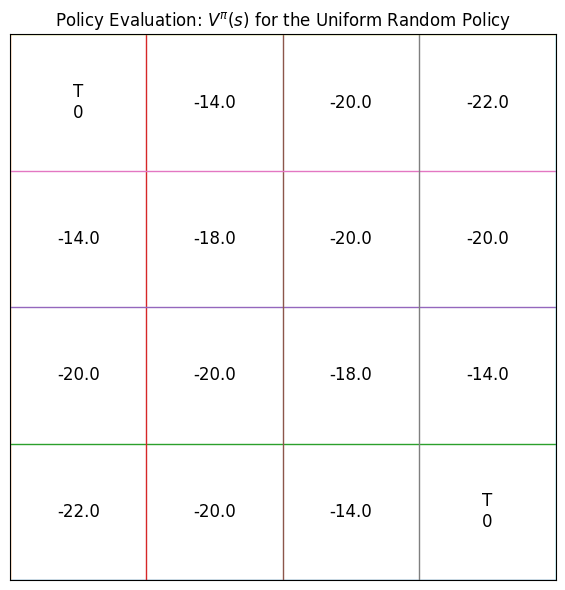

In [4]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.set_aspect("equal")

for i in range(5):
    ax.plot([0, 4], [i, i], linewidth=1)
    ax.plot([i, i], [0, 4], linewidth=1)

for r in range(4):
    for c in range(4):
        x = c + 0.5
        y = 4 - r - 0.5

        if (r, c) in grid.terminals:
            text = "T\n0"
        else:
            text = f"{V_random[(r, c)]:.1f}"

        ax.text(x, y, text, ha="center", va="center", fontsize=12)

ax.set_xticks([])
ax.set_yticks([])
ax.set_title(r"Policy Evaluation: $V^\pi(s)$ for the Uniform Random Policy")
plt.tight_layout()
plt.show()

## 5.3 Policy Improvement: Control Problem

Once $V^\pi$ has been estimated, the policy can be improved by acting greedily with respect to the current values.

For each state,

$$
\boxed{
\pi_{\text{new}}(s)
\in
\arg\max_a
\sum_{s',r}
p(s',r|s,a)
\left[
r+\gamma V^\pi(s')
\right]
}
$$

This is the **control problem**:

> How should the policy be changed to obtain better long-term return?

In the GridWorld, an action that leads toward a higher-valued next state becomes preferable.

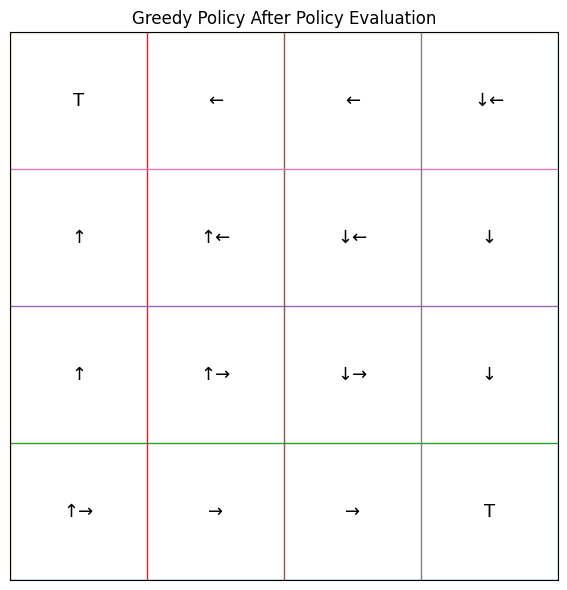

In [5]:
ARROW = {"Up": "↑", "Down": "↓", "Left": "←", "Right": "→"}

def greedy_actions_from_v(env, V, state, gamma=1.0):
    if state in env.terminals:
        return []

    q = {}

    for action in env.actions:
        next_state, reward, done = env.step(state, action)
        q[action] = reward + gamma * V[next_state]

    best = max(q.values())
    return [a for a, value in q.items() if np.isclose(value, best)]

greedy_policy = {
    s: greedy_actions_from_v(grid, V_random, s)
    for s in grid.states
}

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.set_aspect("equal")

for i in range(5):
    ax.plot([0, 4], [i, i], linewidth=1)
    ax.plot([i, i], [0, 4], linewidth=1)

for r in range(4):
    for c in range(4):
        state = (r, c)
        x = c + 0.5
        y = 4 - r - 0.5

        if state in grid.terminals:
            text = "T"
        else:
            text = "".join(ARROW[a] for a in greedy_policy[state])

        ax.text(x, y, text, ha="center", va="center", fontsize=13)

ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Greedy Policy After Policy Evaluation")
plt.tight_layout()
plt.show()

## 5.4 Policy Iteration and Generalized Policy Iteration

Policy iteration repeatedly alternates between:

$$
\boxed{
\text{Policy Evaluation}
\rightarrow
\text{Policy Improvement}
}
$$

The new policy is evaluated, improved again, and the cycle continues until the policy and values converge.

At convergence:

$$
\pi \rightarrow \pi_*
$$

and

$$
V^\pi \rightarrow V_*.
$$

The broader idea of repeatedly allowing evaluation and improvement to interact is called **Generalized Policy Iteration (GPI)**.

A closely related DP algorithm is **value iteration**:

$$
\boxed{
V_{k+1}(s)
=
\max_a
\sum_{s',r}
p(s',r|s,a)
\left[
r+\gamma V_k(s')
\right].
}
$$

## 5.5 Dynamic Programming: Advantages and Limitations

### Advantages

- Uses the complete model to consider possible next states.
- Provides a systematic way to evaluate and improve policies.
- Has clear convergence results for finite MDPs.

### Limitations emphasized in the video

1. **It evaluates every state.**  
   This can become computationally infeasible when the state space is very large, such as in chess.

2. **It requires an environment model.**  
   The transition dynamics may not be available.

3. **It assumes the model contains sufficient environment information.**  
   If the model is incomplete or inaccurate, planning based on it may also be inaccurate.

These limitations motivate methods that learn from sampled experience.

# 6. Monte Carlo Methods

Monte Carlo (MC) methods do **not** require complete knowledge of the environment.

Instead of considering every possible next state through a model, MC methods:

1. interact with the actual environment,
2. sample complete trajectories,
3. calculate returns from those trajectories,
4. use the sampled returns to estimate values.

Thus,

$$
\boxed{
\text{DP uses expected model-based backups}
}
$$

while

$$
\boxed{
\text{MC uses sampled experience}
}
$$

Because the samples come from actual interaction, MC is not dependent on an approximate transition model.

## 6.1 First-Visit Monte Carlo Policy Evaluation

To estimate the **state-value function** for policy $\pi$:

1. Input policy $\pi$.
2. Initialize $V(s)$ arbitrarily.
3. Create an empty return collection for each state.
4. Generate a complete episode following $\pi$.
5. Set

$$
G=0.
$$

6. Move backward through the episode:

$$
G
\leftarrow
\gamma G+R_{t+1}.
$$

7. If $S_t$ has not appeared earlier in the episode, append $G$ to the returns observed for $S_t$.
8. Update

$$
\boxed{
V(S_t)
=
\text{average of the returns observed after visiting }S_t.
}
$$

9. Repeat over many episodes.

This is **first-visit Monte Carlo** because each state is updated only for its first occurrence in an episode.

In [6]:
def generate_random_episode(env, rng, max_steps=1000):
    nonterminal_states = [s for s in env.states if s not in env.terminals]
    state = nonterminal_states[int(rng.integers(len(nonterminal_states)))]
    episode = []

    for _ in range(max_steps):
        action = env.actions[int(rng.integers(len(env.actions)))]
        next_state, reward, done = env.step(state, action)
        episode.append((state, action, reward, next_state))

        if done:
            break

        state = next_state

    return episode

def first_visit_mc_prediction(env, episodes=10000, gamma=1.0, seed=42):
    rng = np.random.default_rng(seed)
    returns = {s: [] for s in env.states}
    V = {s: 0.0 for s in env.states}

    for _ in range(episodes):
        episode = generate_random_episode(env, rng)
        G = 0.0
        visited_from_start = {state: i for i, (state, _, _, _) in enumerate(episode)}

        # Compute returns backward.
        returns_from_t = [0.0] * len(episode)

        for t in reversed(range(len(episode))):
            _, _, reward, _ = episode[t]
            G = gamma * G + reward
            returns_from_t[t] = G

        # First occurrence of each state in the episode.
        seen = set()

        for t, (state, _, _, _) in enumerate(episode):
            if state not in seen:
                seen.add(state)
                returns[state].append(returns_from_t[t])
                V[state] = np.mean(returns[state])

    return V

V_mc = first_visit_mc_prediction(grid)

comparison_mc = pd.DataFrame({
    "State": [s for s in grid.states if s not in grid.terminals],
    "DP V^pi": [V_random[s] for s in grid.states if s not in grid.terminals],
    "MC estimate": [V_mc[s] for s in grid.states if s not in grid.terminals],
})

comparison_mc.head(10).round(2)

,State,DP V^pi,MC estimate
0,"(0, 1)",-14.0,-14.14
1,"(0, 2)",-20.0,-20.16
2,"(0, 3)",-22.0,-22.16
3,"(1, 0)",-14.0,-14.19
4,"(1, 1)",-18.0,-18.14
5,"(1, 2)",-20.0,-20.20
6,"(1, 3)",-20.0,-19.76
7,"(2, 0)",-20.0,-20.27
8,"(2, 1)",-20.0,-19.99
9,"(2, 2)",-18.0,-18.36


## 6.2 Monte Carlo Control with Action Values

State values are convenient when a model is available because the model can be used to compare actions.

In a model-free control setting, it is more useful to estimate

$$
Q(s,a),
$$

because the action values directly compare the available actions.

A first-visit MC control procedure follows the same basic idea:

1. Initialize policy $\pi$ and $Q(s,a)$.
2. Keep returns for each state-action pair.
3. Generate an episode.
4. Traverse the episode backward and compute $G$.
5. For a first occurrence of $(S_t,A_t)$, append $G$ to its return collection.
6. Update

$$
Q(S_t,A_t)
=
\text{average return observed after }(S_t,A_t).
$$

7. Improve the policy by selecting the action with the largest action value:

$$
\boxed{
\pi(s)
\leftarrow
\arg\max_a Q(s,a).
}
$$

In practical MC control, sufficient exploration must be maintained so that useful state-action pairs continue to be sampled.

## 6.3 Monte Carlo: Advantages and Limitations

### Advantages

- Does not require an explicit environment model.
- Learns from actual sampled trajectories.
- Uses complete observed returns rather than bootstrapping from another value estimate.
- Conceptually simple.

### Main limitation emphasized in the video

MC normally waits until the **end of an episode** before the complete return is known.

For a short episode this may be acceptable. For a long episode, learning can be very slow because no update is made until termination.

This motivates **one-step learning**.

# 7. Temporal-Difference Methods

Temporal-Difference (TD) methods update values **after individual transitions** rather than waiting for a full trajectory.

A Monte Carlo target is the complete return:

$$
G_t.
$$

A one-step TD target is

$$
\boxed{
R_{t+1}
+
\gamma V(S_{t+1})
}
$$

The TD error is

$$
\boxed{
\delta_t
=
R_{t+1}
+
\gamma V(S_{t+1})
-
V(S_t).
}
$$

The TD(0) update is

$$
\boxed{
V(S_t)
\leftarrow
V(S_t)
+
\alpha\delta_t.
}
$$

TD is said to **bootstrap** because the update uses the current estimate of the next state's value.

## 7.1 TD(0) Policy Evaluation Algorithm

Given policy $\pi$:

1. Choose learning rate $\alpha$.
2. Initialize $V(s)$ arbitrarily, with terminal-state value set to $0$.
3. For each episode, initialize state $S$.
4. Choose action $A$ according to $\pi$.
5. Take the action and observe reward $R$ and next state $S'$.
6. Update

$$
V(S)
\leftarrow
V(S)
+
\alpha
\left[
R+\gamma V(S')-V(S)
\right].
$$

7. Set

$$
S\leftarrow S'
$$

and continue until termination.

Unlike MC, TD learns while the episode is still in progress.

In [7]:
def td0_prediction(env, episodes=10000, alpha=0.05, gamma=1.0, seed=42):
    rng = np.random.default_rng(seed)
    V = {s: 0.0 for s in env.states}

    nonterminal_states = [s for s in env.states if s not in env.terminals]

    for _ in range(episodes):
        state = nonterminal_states[int(rng.integers(len(nonterminal_states)))]

        for _ in range(1000):
            action = env.actions[int(rng.integers(len(env.actions)))]
            next_state, reward, done = env.step(state, action)

            target = reward if done else reward + gamma * V[next_state]
            V[state] += alpha * (target - V[state])

            if done:
                break

            state = next_state

    return V

V_td = td0_prediction(grid)

comparison_td = pd.DataFrame({
    "State": [s for s in grid.states if s not in grid.terminals],
    "DP V^pi": [V_random[s] for s in grid.states if s not in grid.terminals],
    "TD estimate": [V_td[s] for s in grid.states if s not in grid.terminals],
})

comparison_td.head(10).round(2)

,State,DP V^pi,TD estimate
0,"(0, 1)",-14.0,-14.23
1,"(0, 2)",-20.0,-19.64
2,"(0, 3)",-22.0,-22.34
3,"(1, 0)",-14.0,-11.29
4,"(1, 1)",-18.0,-17.67
5,"(1, 2)",-20.0,-20.39
6,"(1, 3)",-20.0,-20.75
7,"(2, 0)",-20.0,-20.58
8,"(2, 1)",-20.0,-20.37
9,"(2, 2)",-18.0,-18.24


## 7.2 Monte Carlo vs. TD

| Property | Monte Carlo | TD(0) |
|---|---|---|
| Model required | No | No |
| Learns from samples | Yes | Yes |
| Waits until episode ends | Yes | No |
| Target | Complete return $G_t$ | $R_{t+1}+\gamma V(S_{t+1})$ |
| Bootstraps | No | Yes |
| Online one-step updates | No | Yes |

The video emphasizes that TD is **truly online** because it can revise an estimate immediately after new information arrives.

## 7.3 $n$-Step Bootstrapping

One-step TD and full-return Monte Carlo are two ends of a spectrum.

An $n$-step method uses several observed rewards before bootstrapping:

$$
\boxed{
G_{t:t+n}
=
R_{t+1}
+
\gamma R_{t+2}
+
\cdots
+
\gamma^{n-1}R_{t+n}
+
\gamma^nV(S_{t+n}).
}
$$

Thus,

$$
\boxed{
\text{1-step TD}
\longleftrightarrow
\text{$n$-step methods}
\longleftrightarrow
\text{Monte Carlo}
}
$$

$n$-step methods provide a middle ground between short bootstrapped updates and complete returns.

### Additional practical notes about TD

**Advantages**

- Learns after every transition.
- Works naturally with long or continuing interaction.
- Often has lower variance than complete-return MC updates.

**Limitations**

- Bootstraps from current estimates, so inaccurate estimates can influence other estimates.
- Learning depends on the choice of step size $\alpha$.

# 8. Driving-Home Example: Monte Carlo vs. TD

The video uses a driving-home example to make the difference between MC and TD concrete.

The trip begins at **6:00 PM**.

| Checkpoint | Elapsed time from 6:00 | Predicted time remaining |
|---|---:|---:|
| Leave office | 0 min | 30 min |
| Reach car, rain starts | 5 min | 35 min |
| Exit highway | 20 min | 15 min |
| Secondary road, stuck behind slow truck | not stated explicitly in the transcript | 10 min |
| Enter home street | 40 min | 3 min |
| Arrive home | 43 min | 0 min |

The total trip actually takes

$$
\boxed{
43\text{ minutes}.
}
$$

For this example, the video sets

$$
\gamma=1
\qquad\text{and}\qquad
\alpha=1.
$$

## 8.1 Modeling the Trip as an RL Prediction Problem

- **States:** the checkpoints during the trip.
- **Rewards:** elapsed travel time between checkpoints.
- **Return:** actual time remaining until home.
- **State value:** predicted time remaining from the current checkpoint.

For example, reaching the car takes $5$ minutes, so the first transition contributes a reward of $5$.

At the highway exit, the elapsed time is $20$ minutes, so the time spent since reaching the car is

$$
20-5=15\text{ minutes}.
$$

## 8.2 Monte Carlo Update

MC waits until home is reached.

Once the actual arrival time is known, predictions can be moved toward the actual remaining travel time.

For the initial state,

$$
\text{predicted}=30\text{ min},
$$

but the actual return is

$$
43\text{ min}.
$$

With $\alpha=1$, MC replaces the old prediction with the observed complete outcome.

## 8.3 TD Update

TD does not need to wait until arrival.

For example, when moving from one checkpoint to the next, the target is

$$
\boxed{
\text{elapsed segment time}
+
\text{next checkpoint's predicted time remaining}.
}
$$

So TD updates the current prediction toward the next prediction plus the time just spent.

This explains the key distinction:

$$
\boxed{
\text{MC learns from the final outcome}
}
$$

whereas

$$
\boxed{
\text{TD learns from the next prediction during the episode}.
}
$$

## 8.4 Why Online Updating Matters

The video considers leaving work again on another day and getting trapped in a major traffic jam.

A Monte Carlo method would still wait until the trip is complete before using the final travel time.

A TD method can revise the estimated time-to-go **while still stuck in traffic**, because every new transition provides a one-step learning target.

The intuition is that a prediction made later in a trajectory often contains newer information than an earlier prediction. The video also relates this idea to a chess game: a prediction made near the end of the game may be more informed than one made after only the opening moves.

# 9. SARSA

SARSA is a **model-free, on-policy TD control** algorithm.

Its update uses

$$
S_t,\ A_t,\ R_{t+1},\ S_{t+1},\ A_{t+1},
$$

which gives the name **SARSA**.

The update is

$$
\boxed{
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma Q(S_{t+1},A_{t+1})
-
Q(S_t,A_t)
\right].
}
$$

The TD target is

$$
\boxed{
R_{t+1}
+
\gamma Q(S_{t+1},A_{t+1}).
}
$$

## 9.1 SARSA Algorithm

1. Initialize $\alpha$, $\epsilon$, and $Q(s,a)$.
2. Set terminal-state action values to $0$.
3. For each episode:
   - initialize state $S$,
   - choose action $A$ from a policy derived from $Q$, often $\epsilon$-greedy.
4. Take action $A$.
5. Observe reward $R$ and next state $S'$.
6. Choose the next action $A'$ using the **same policy**.
7. Update

$$
Q(S,A)
\leftarrow
Q(S,A)
+
\alpha
\left[
R+\gamma Q(S',A')-Q(S,A)
\right].
$$

8. Set

$$
S\leftarrow S',
\qquad
A\leftarrow A'.
$$

9. Repeat until a terminal state is reached.

## 9.2 Windy GridWorld Example

The video applies SARSA to a **Windy GridWorld**:

- the agent starts from a specified cell,
- the goal is to reach a target cell,
- wind pushes the agent upward in affected parts of the grid.

As learning proceeds, the agent reaches the goal more quickly. The increasing slope of the learning curve indicates that more episodes are completed in the same amount of interaction time.

The example also illustrates a limitation of pure episodic Monte Carlo learning: if an agent can wander indefinitely, termination is not guaranteed, so MC may have to wait indefinitely for a complete return.

SARSA avoids that particular problem because it learns **during** the episode through one-step TD updates.

## 9.3 On-Policy Learning

SARSA is **on-policy**.

An on-policy method evaluates or improves the same policy that is used to generate actions.

If the behavior policy is $\epsilon$-greedy, the learned values therefore reflect the consequences of that exploratory behavior.

### SARSA: Advantages and Limitations

**Advantages**

- Model-free.
- Learns online after each transition.
- Directly incorporates the behavior policy into learning.
- Can learn more cautious behavior when exploratory actions have important consequences.

**Limitations**

- The learned values depend on the behavior policy.
- Persistent exploration can keep the learned policy different from the purely greedy policy.
- Performance depends on choices such as $\alpha$, $\epsilon$, and $\gamma$.

# 10. On-Policy vs. Off-Policy Learning

### On-Policy

The policy used to generate behavior is the same policy being evaluated or improved.

$$
\boxed{
\text{behavior policy}
=
\text{target policy}
}
$$

SARSA is the main example in this video.

### Off-Policy

The agent behaves according to one policy but learns about another:

$$
\boxed{
\text{behavior policy}
\neq
\text{target policy}.
}
$$

The **behavior policy** is often exploratory.

The **target policy** can be greedy or closer to optimal.

### Why Separate the Two?

To discover which actions are best, an agent may need to behave non-greedily and explore.

Off-policy learning allows the agent to

$$
\boxed{
\text{explore with one policy}
}
$$

while simultaneously

$$
\boxed{
\text{learning values for a different, greedy target policy}.
}
$$

This separation is the motivation for Q-learning.

# 11. Q-Learning

Q-learning is a **model-free, off-policy TD control** algorithm.

Its update is

$$
\boxed{
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma
\max_a Q(S_{t+1},a)
-
Q(S_t,A_t)
\right].
}
$$

The target is

$$
\boxed{
R_{t+1}
+
\gamma
\max_a Q(S_{t+1},a).
}
$$

Unlike SARSA, the target does not use the next action actually selected by the exploratory behavior policy. It uses the **best estimated action value** at the next state.

## 11.1 Q-Learning Algorithm

1. Initialize $Q(s,a)$.
2. For each episode, initialize state $S$.
3. Choose action $A$ using a behavior policy such as $\epsilon$-greedy.
4. Take $A$ and observe $R$ and $S'$.
5. Compute

$$
\max_{a'}Q(S',a').
$$

6. Update

$$
Q(S,A)
\leftarrow
Q(S,A)
+
\alpha
\left[
R+\gamma\max_{a'}Q(S',a')-Q(S,A)
\right].
$$

7. Set

$$
S\leftarrow S'
$$

and continue until termination.

The behavior policy can remain exploratory even though the update targets the greedy action value.

### Additional practical notes about Q-learning

**Advantages**

- Model-free.
- Learns online.
- Separates exploratory behavior from the greedy target policy.
- In the tabular setting, it can converge to optimal action values under standard conditions.

**Limitations**

- The maximization step can overestimate values when estimates are noisy.
- A tabular $Q$ function becomes impractical in very large or continuous state spaces.
- Exploration and learning-rate choices still matter.

# 12. SARSA vs. Q-Learning

The algorithms differ in the next-state value used in the TD target.

### SARSA

$$
\boxed{
R_{t+1}
+
\gamma Q(S_{t+1},A_{t+1})
}
$$

The next action is the action actually selected by the current behavior policy.

### Q-Learning

$$
\boxed{
R_{t+1}
+
\gamma\max_a Q(S_{t+1},a)
}
$$

The target assumes the greedy next action.

| Property | SARSA | Q-Learning |
|---|---|---|
| Method | TD control | TD control |
| Model required | No | No |
| Policy relation | On-policy | Off-policy |
| Behavior policy | Often $\epsilon$-greedy | Often $\epsilon$-greedy |
| Target uses | Actual next action | Greedy next-action value |
| Exploration directly affects target | Yes | No |

## 12.1 Cliff-Walking Example

The video compares SARSA and Q-learning on a $4\times12$ grid:

- start state $S$ is at the lower-left corner,
- goal state $G$ is at the lower-right corner,
- the cells between them on the lower row form a cliff,
- ordinary transitions give reward $-1$,
- entering the cliff gives reward $-100$ and terminates the episode.

With an $\epsilon$-greedy behavior policy:

- **Q-learning** learns the shortest greedy path close to the cliff.
- **SARSA** learns a safer path farther from the cliff because its update accounts for the exploratory behavior actually being followed.

The key point is that a path can be optimal under purely greedy behavior but risky when the behavior policy still explores.

In [8]:
ROWS, COLS = 4, 12
START = (3, 0)
GOAL = (3, 11)
CLIFF = {(3, c) for c in range(1, 11)}

CLIFF_ACTIONS = {
    0: (-1, 0),   # Up
    1: (1, 0),    # Down
    2: (0, -1),   # Left
    3: (0, 1),    # Right
}

ACTION_NAMES = {0: "Up", 1: "Down", 2: "Left", 3: "Right"}

cliff_states = [
    (r, c)
    for r in range(ROWS)
    for c in range(COLS)
    if (r, c) not in CLIFF
]

state_to_index = {s: i for i, s in enumerate(cliff_states)}

def cliff_step(state, action):
    r, c = state
    dr, dc = CLIFF_ACTIONS[action]

    nr = min(max(r + dr, 0), ROWS - 1)
    nc = min(max(c + dc, 0), COLS - 1)
    next_state = (nr, nc)

    if next_state in CLIFF:
        return next_state, -100, True

    if next_state == GOAL:
        return next_state, -1, True

    return next_state, -1, False

def epsilon_greedy_index(q_values, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(len(q_values)))

    best = np.flatnonzero(np.isclose(q_values, np.max(q_values)))
    return int(rng.choice(best))

In [9]:
def train_sarsa_cliff(
    episodes=10000,
    alpha=0.5,
    gamma=1.0,
    epsilon=0.1,
    seed=42,
):
    rng = np.random.default_rng(seed)
    Q = np.zeros((len(cliff_states), 4))
    episode_returns = []

    for _ in range(episodes):
        state = START
        s_idx = state_to_index[state]
        action = epsilon_greedy_index(Q[s_idx], epsilon, rng)
        total_reward = 0

        for _ in range(1000):
            next_state, reward, done = cliff_step(state, action)
            total_reward += reward

            if done:
                target = reward
                Q[s_idx, action] += alpha * (target - Q[s_idx, action])
                break

            next_idx = state_to_index[next_state]
            next_action = epsilon_greedy_index(Q[next_idx], epsilon, rng)

            target = reward + gamma * Q[next_idx, next_action]
            Q[s_idx, action] += alpha * (target - Q[s_idx, action])

            state = next_state
            s_idx = next_idx
            action = next_action

        episode_returns.append(total_reward)

    return Q, np.asarray(episode_returns)

def train_q_learning_cliff(
    episodes=10000,
    alpha=0.5,
    gamma=1.0,
    epsilon=0.1,
    seed=42,
):
    rng = np.random.default_rng(seed)
    Q = np.zeros((len(cliff_states), 4))
    episode_returns = []

    for _ in range(episodes):
        state = START
        total_reward = 0

        for _ in range(1000):
            s_idx = state_to_index[state]
            action = epsilon_greedy_index(Q[s_idx], epsilon, rng)

            next_state, reward, done = cliff_step(state, action)
            total_reward += reward

            if done:
                target = reward
            else:
                next_idx = state_to_index[next_state]
                target = reward + gamma * np.max(Q[next_idx])

            Q[s_idx, action] += alpha * (target - Q[s_idx, action])

            if done:
                break

            state = next_state

        episode_returns.append(total_reward)

    return Q, np.asarray(episode_returns)

Q_sarsa, returns_sarsa = train_sarsa_cliff()
Q_q, returns_q = train_q_learning_cliff()

In [10]:
def greedy_path(Q, max_steps=100):
    state = START
    path = [state]

    for _ in range(max_steps):
        if state == GOAL:
            break

        action = int(np.argmax(Q[state_to_index[state]]))
        next_state, reward, done = cliff_step(state, action)
        path.append(next_state)

        if done:
            break

        state = next_state

    return path

sarsa_path = greedy_path(Q_sarsa)
q_path = greedy_path(Q_q)

print("SARSA greedy path:")
print(sarsa_path)

print("\nQ-learning greedy path:")
print(q_path)

SARSA greedy path:
[(3, 0), (2, 0), (1, 0), (0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (1, 11), (2, 11), (3, 11)]

Q-learning greedy path:
[(3, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (3, 11)]


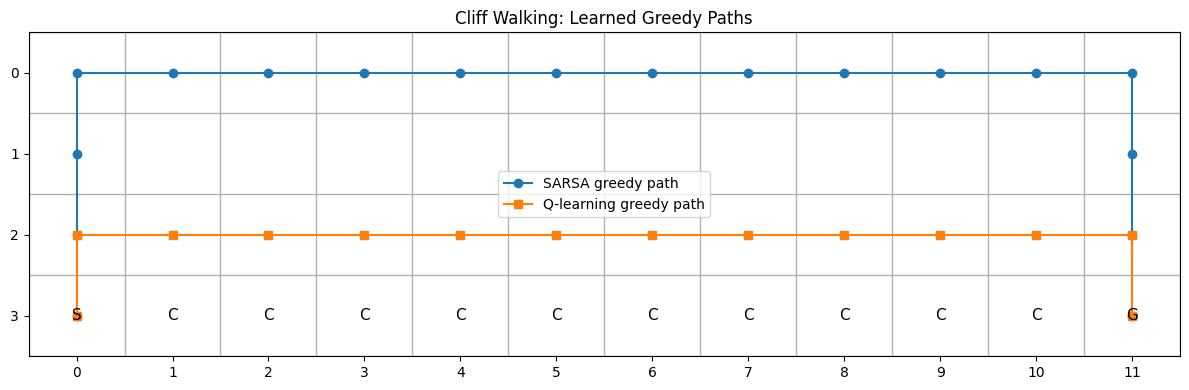

In [11]:
def plot_cliff_paths(sarsa_path, q_path):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.set_xlim(-0.5, COLS - 0.5)
    ax.set_ylim(ROWS - 0.5, -0.5)
    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))
    ax.set_xticks(np.arange(-0.5, COLS, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, ROWS, 1), minor=True)
    ax.grid(which="minor", linewidth=1)
    ax.tick_params(which="minor", bottom=False, left=False)

    for r in range(ROWS):
        for c in range(COLS):
            state = (r, c)

            if state == START:
                label = "S"
            elif state == GOAL:
                label = "G"
            elif state in CLIFF:
                label = "C"
            else:
                label = ""

            if label:
                ax.text(c, r, label, ha="center", va="center", fontsize=11)

    sarsa_xy = [(c, r) for r, c in sarsa_path if (r, c) not in CLIFF]
    q_xy = [(c, r) for r, c in q_path if (r, c) not in CLIFF]

    ax.plot(
        [x for x, y in sarsa_xy],
        [y for x, y in sarsa_xy],
        marker="o",
        label="SARSA greedy path",
    )

    ax.plot(
        [x for x, y in q_xy],
        [y for x, y in q_xy],
        marker="s",
        label="Q-learning greedy path",
    )

    ax.set_title("Cliff Walking: Learned Greedy Paths")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_cliff_paths(sarsa_path, q_path)

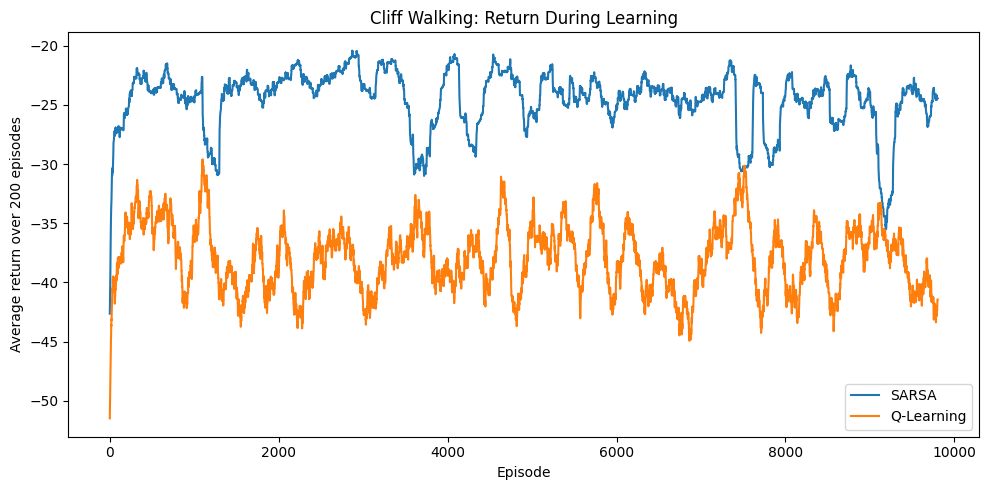

Mean return over the last 1,000 episodes
SARSA: -26.31
Q-Learning: -38.49


In [12]:
window = 200

sarsa_ma = np.convolve(
    returns_sarsa,
    np.ones(window) / window,
    mode="valid",
)

q_ma = np.convolve(
    returns_q,
    np.ones(window) / window,
    mode="valid",
)

plt.figure(figsize=(10, 5))
plt.plot(sarsa_ma, label="SARSA")
plt.plot(q_ma, label="Q-Learning")
plt.xlabel("Episode")
plt.ylabel(f"Average return over {window} episodes")
plt.title("Cliff Walking: Return During Learning")
plt.legend()
plt.tight_layout()
plt.show()

print("Mean return over the last 1,000 episodes")
print("SARSA:", round(returns_sarsa[-1000:].mean(), 2))
print("Q-Learning:", round(returns_q[-1000:].mean(), 2))

The numerical run above illustrates the same qualitative point as the video: under continued $\epsilon$-greedy exploration, SARSA can learn a route that keeps more distance from the cliff, while Q-learning targets the greedy shortest route.

The video emphasizes that off-policy learning is powerful because it can continue exploring with the behavior policy while learning a different, greedy target policy. The cliff example also shows why the policy that looks optimal under greedy execution may not collect the most reward while exploratory actions are still occurring.

# 13. Complete Algorithm Comparison

| Property | Dynamic Programming | Monte Carlo | TD(0) | SARSA | Q-Learning |
|---|---|---|---|---|---|
| Uses a model | Yes | No | No | No | No |
| Learns from sampled experience | Not required | Yes | Yes | Yes | Yes |
| Main value used in basic form | $V(s)$ | $V(s)$ or $Q(s,a)$ | $V(s)$ | $Q(s,a)$ | $Q(s,a)$ |
| Must wait for episode end | No | Yes | No | No | No |
| Bootstraps | Yes | No | Yes | Yes | Yes |
| Main target | Bellman expectation | $G_t$ | $R+\gamma V(S')$ | $R+\gamma Q(S',A')$ | $R+\gamma\max_aQ(S',a)$ |
| Prediction / control | Both | Both | Prediction in TD(0) form | Control | Control |
| On-/off-policy | Depends on method | Can be either | Depends on method | On-policy | Off-policy |
| Main strength | Full planning with known model | Model-free complete-return learning | Online learning | Learns current exploratory policy | Learns greedy target while exploring |
| Main limitation | Requires model and full sweeps | Waits for complete episodes | Bootstraps from estimates | Exploration affects learned policy | Greedy target can be risky during exploratory behavior |

## 13.1 How the Methods Build on One Another

### Dynamic Programming

$$
\boxed{
\text{Known model}
+
\text{Bellman backups}
}
$$

### Monte Carlo

$$
\boxed{
\text{No model}
+
\text{sampled complete returns}
}
$$

### Temporal Difference

$$
\boxed{
\text{No model}
+
\text{sampling}
+
\text{bootstrapping}
}
$$

### SARSA

$$
\boxed{
\text{TD}
+
Q(s,a)
+
\text{on-policy control}
}
$$

### Q-Learning

$$
\boxed{
\text{TD}
+
Q(s,a)
+
\text{off-policy control}
}
$$

# 14. Key Equations

### MDP dynamics

$$
p(s',r|s,a)
=
P(S_{t+1}=s',R_{t+1}=r
\mid S_t=s,A_t=a)
$$

### State value

$$
V^\pi(s)
=
\mathbb E_\pi[G_t\mid S_t=s]
$$

### Action value

$$
Q^\pi(s,a)
=
\mathbb E_\pi[G_t\mid S_t=s,A_t=a]
$$

### Bellman expectation equation

$$
V^\pi(s)
=
\sum_a
\pi(a|s)
\sum_{s',r}
p(s',r|s,a)
\left[
r+\gamma V^\pi(s')
\right]
$$

### Monte Carlo return recursion

$$
G
\leftarrow
\gamma G+R
$$

### TD(0)

$$
V(S_t)
\leftarrow
V(S_t)
+
\alpha
\left[
R_{t+1}
+
\gamma V(S_{t+1})
-
V(S_t)
\right]
$$

### SARSA

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma Q(S_{t+1},A_{t+1})
-
Q(S_t,A_t)
\right]
$$

### Q-Learning

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma\max_a Q(S_{t+1},a)
-
Q(S_t,A_t)
\right]
$$

# 15. Final Takeaways

1. An MDP describes the agent–environment interaction, and the Markov property allows the next transition to be described using the current state and action rather than the complete history.
2. A model predicts how the environment will respond and enables model-based planning.
3. Action values make it possible to compare actions directly when an explicit model is unavailable.
4. $\epsilon$-greedy action selection balances exploration and exploitation, and $\epsilon$ can be reduced during training.
5. Dynamic Programming alternates policy evaluation and policy improvement and requires a model.
6. Monte Carlo learns from complete sampled trajectories without a model.
7. TD learns from one-step experience and bootstraps from the next value estimate.
8. $n$-step methods lie between one-step TD and full-return Monte Carlo.
9. SARSA is an on-policy TD control method.
10. Q-learning is an off-policy TD control method.
11. The cliff-walking example shows how SARSA's exploratory behavior can favor a safer route while Q-learning learns a greedy route closer to the cliff.